In [2]:

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
pd.options.mode.chained_assignment = None

import pyfade

In [3]:
PUMP = 'B-18 2'
SOURCE = 'C:/Users/Heitor/Documents/PosDoc/code/EPIC/Dados/merged_data.csv'
EXAMPLE_SIGNAL = 'ESP intake Pressure'
# EXAMPLE_SIGNAL = None

In [4]:
WAVELET = 'db2'
IGNORE_START = True
QUANTILE = 0.75
SUB_SIZE = 1*24
DIMENSION = 3
LEVELS = 5
USE_CUDA = True
SKIP_START=SUB_SIZE*5
LEFT_ONLY=True

# 1 - Reading Signal

In [5]:
# Load well data
if 'well_data' not in locals():
    data_full = pyfade.load_data(SOURCE)
    well_data = pyfade.get_well_data(data_full, PUMP, only_numerical=True, remove_ints=True, drop_na=True, drop_features = True)

shutdowns_all = pyfade.get_shutdowns(well_data)

In [6]:
if EXAMPLE_SIGNAL is not None:
    sub_data = well_data[EXAMPLE_SIGNAL]
    shutdowns = [shutdowns_all[well_data.columns.get_loc(EXAMPLE_SIGNAL)]]
else:
    sub_data = well_data.copy()
    shutdowns = shutdowns_all



# 2 - MP raw

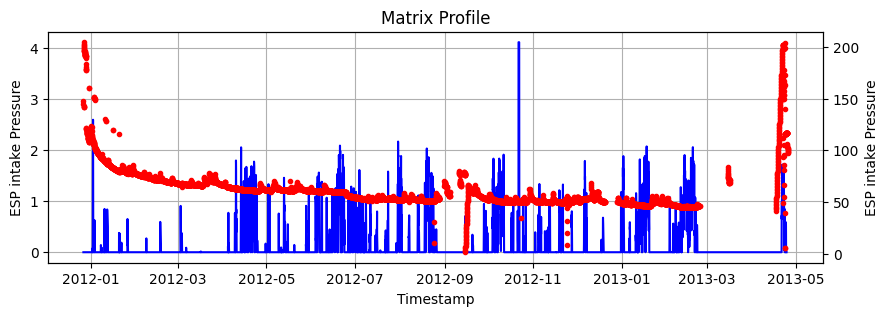

In [7]:
builder = pyfade.DataFrameBuilder(sub_data)
dataset = builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .build()

w_builder = pyfade.WindowBuilder(dataset)
window = w_builder.set_window_size(SUB_SIZE).build()

group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.MatrixProfile, window)
group_builder.set_parameter('use_cuda',USE_CUDA)\
            .set_parameter('left_only',LEFT_ONLY)\
            .set_parameter('skip_start',SKIP_START)\
            .set_parameter('quantile_threshold',QUANTILE)
group_builder.build()

MP = pd.DataFrame(window.mp.T,index=window.index)
fig, axs = pyfade.plot_multiple(MP,ylabel=dataset.dimensions,height=3,width=10);

pyfade.plot_multiple(sub_data,style='r.',axs=axs,fig=fig);

axs[0].set_title('Matrix Profile');


c:\Users\Heitor\anaconda3\envs\pyfade\Lib\site-packages\pyfade\plot.py:210: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, axs = plt.subplots(num_dim, sharex=True, gridspec_kw={'hspace': HSPACE},figsize=[width,height*num_dim])


(<Figure size 1000x300 with 2 Axes>,
 [<Axes: xlabel='Timestamp', ylabel='ESP intake Pressure'>])

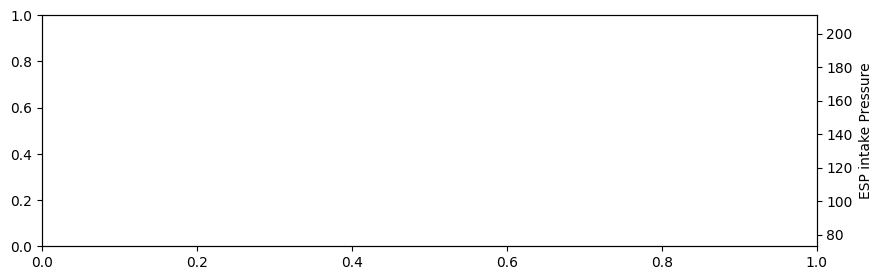

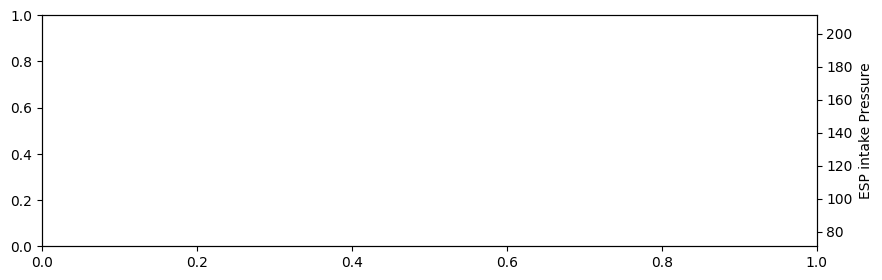

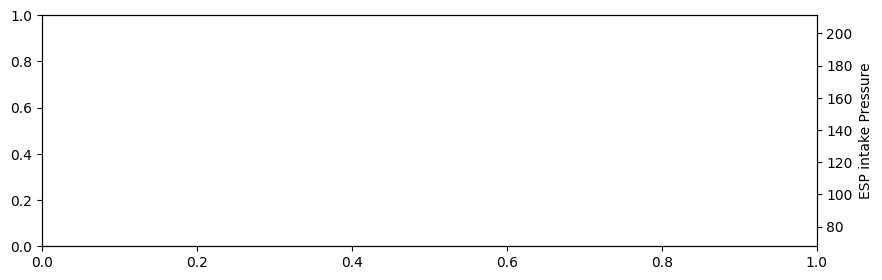

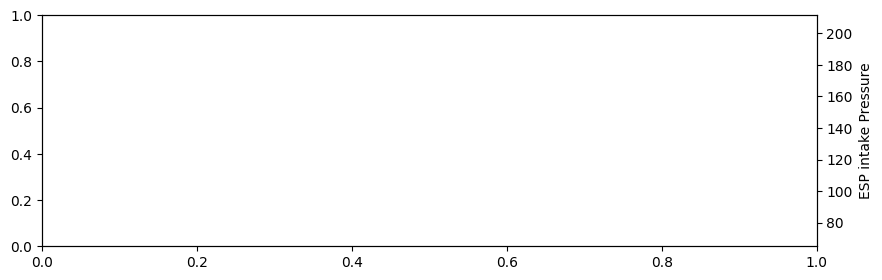

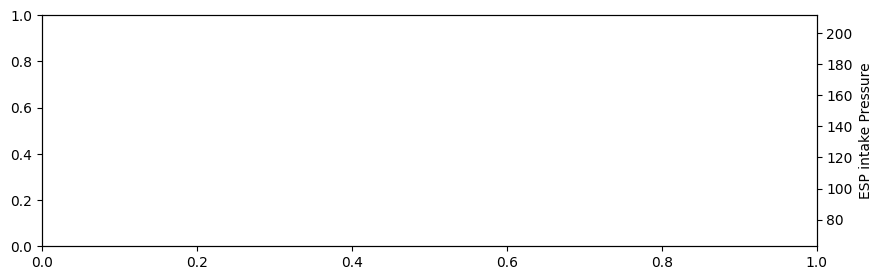

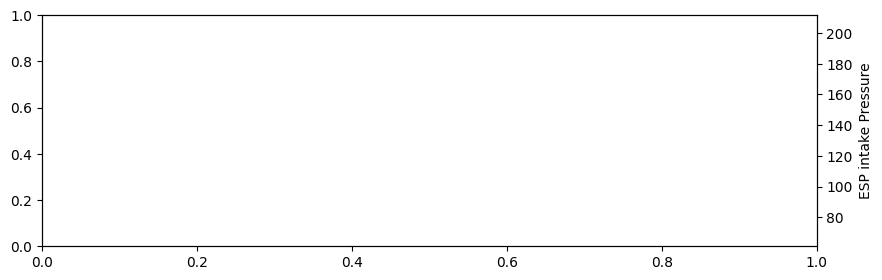

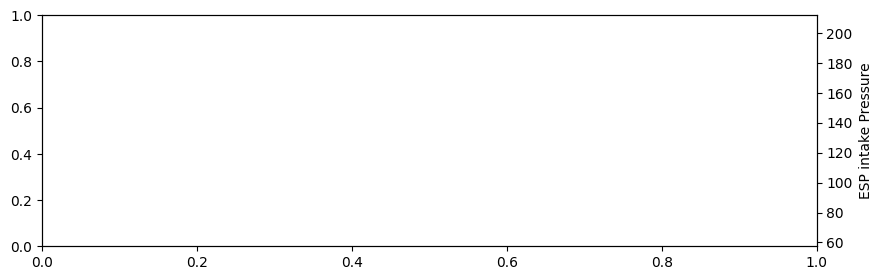

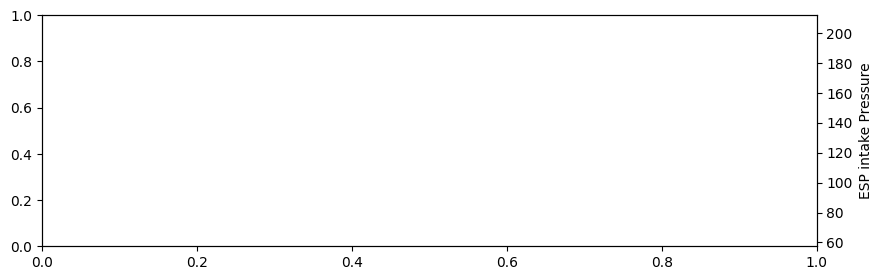

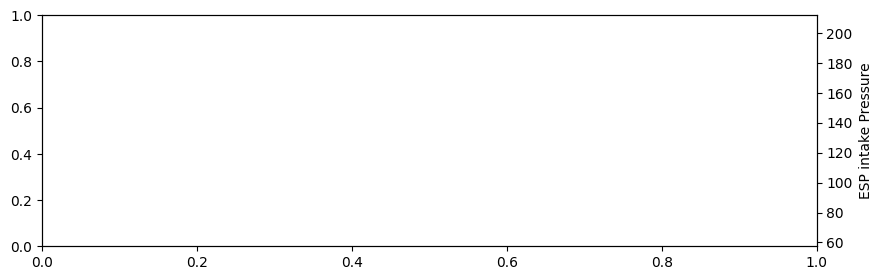

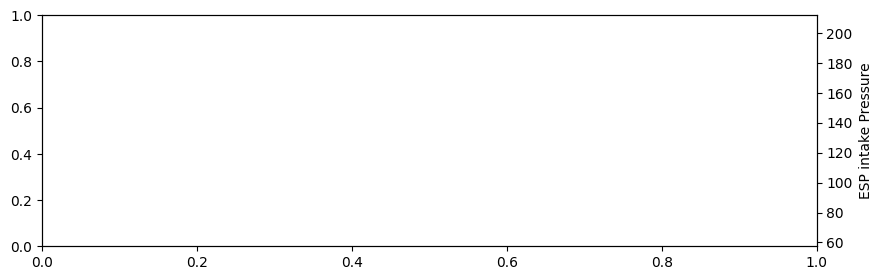

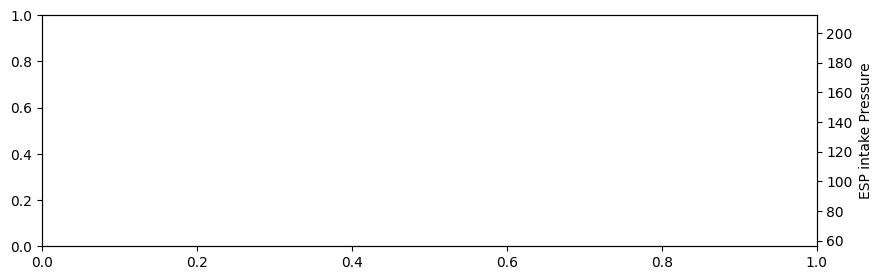

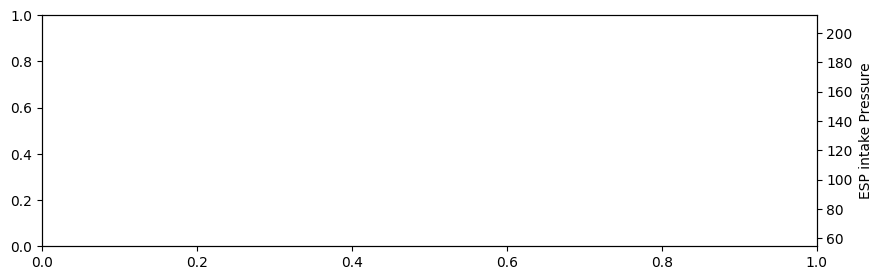

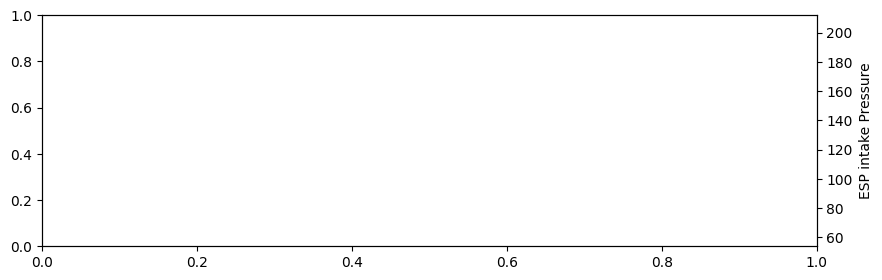

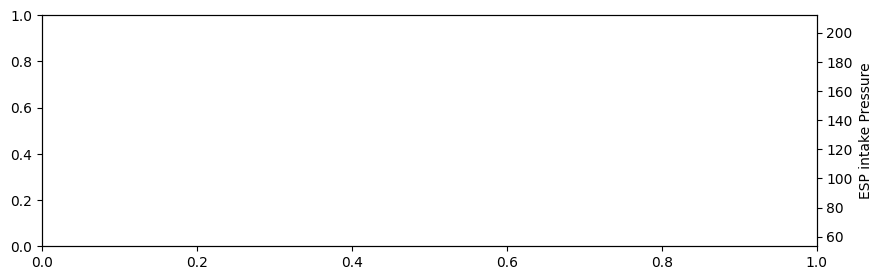

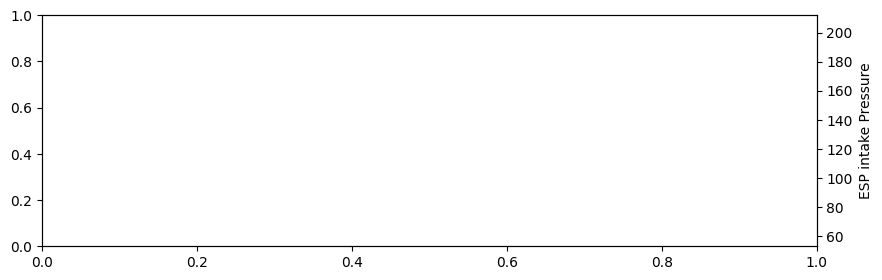

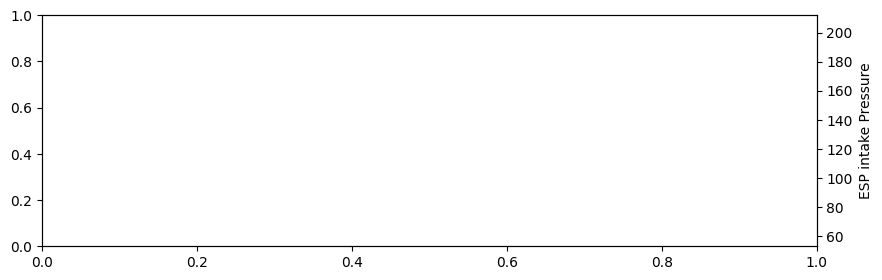

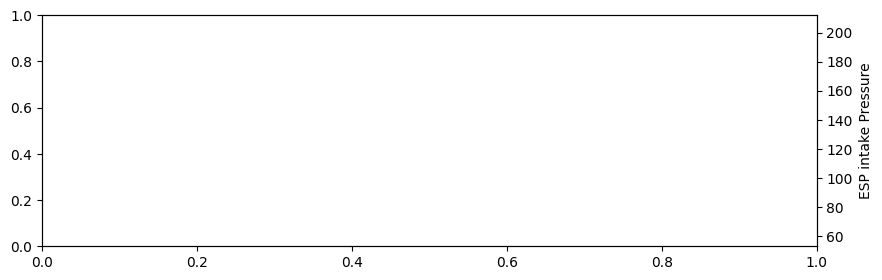

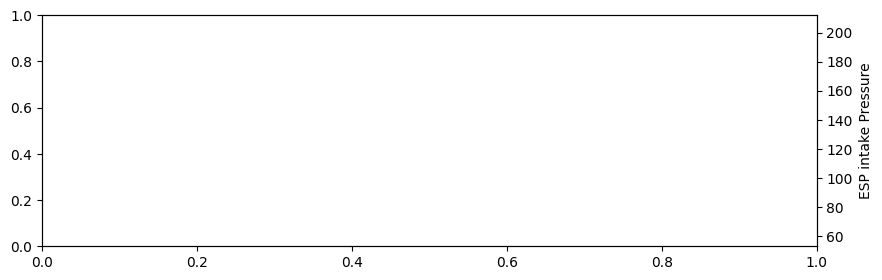

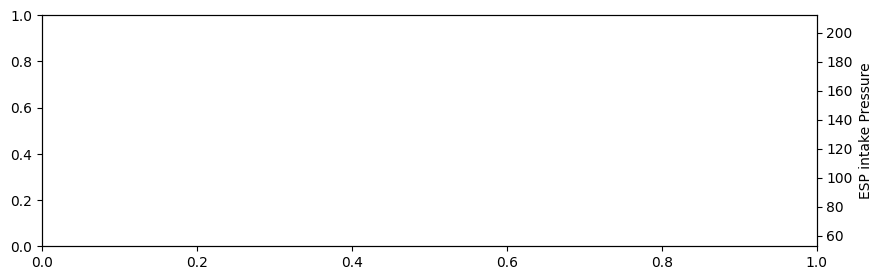

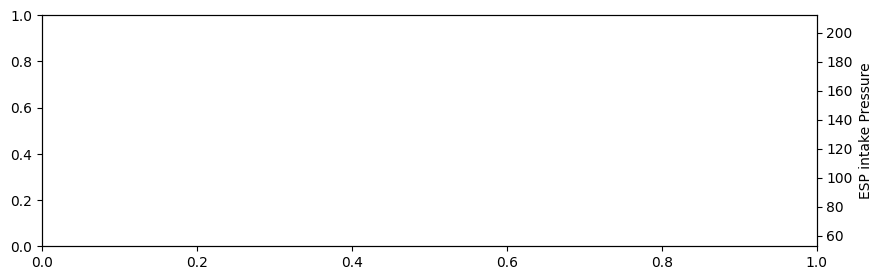

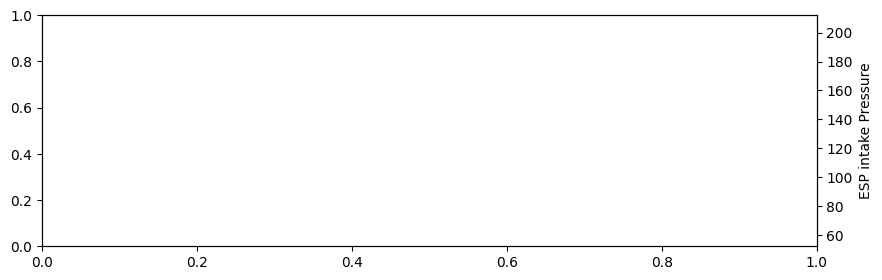

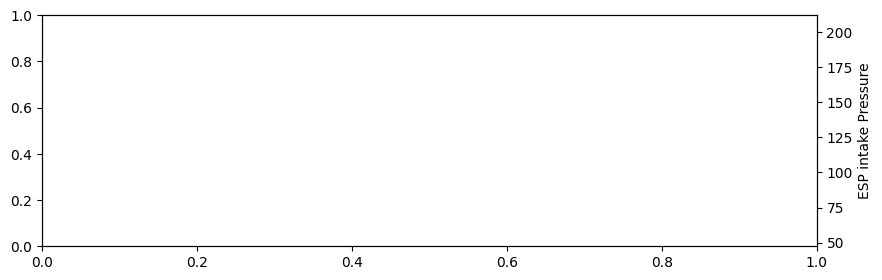

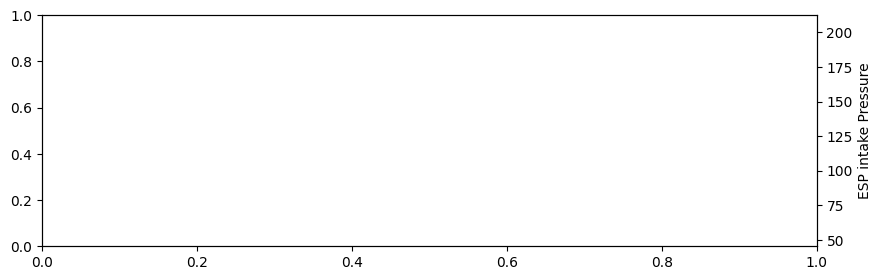

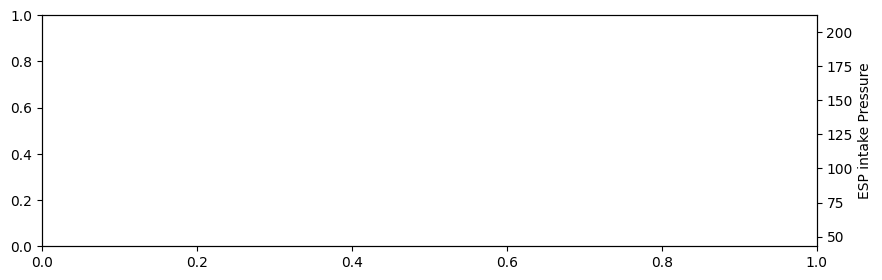

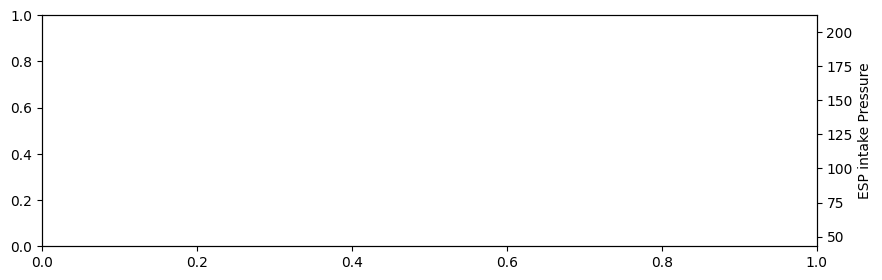

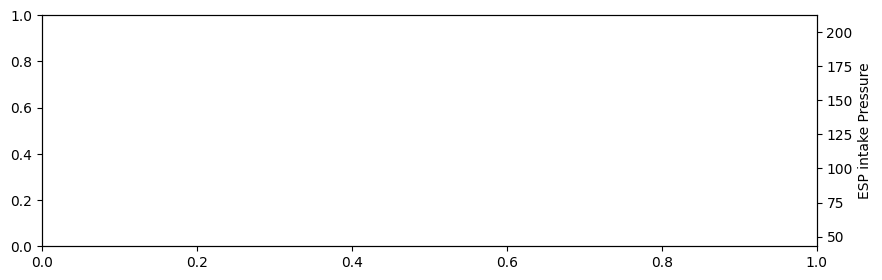

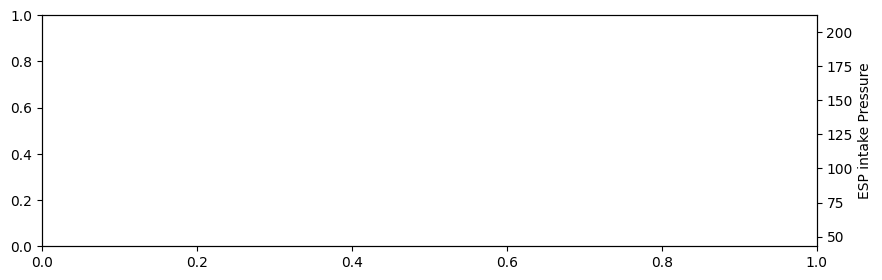

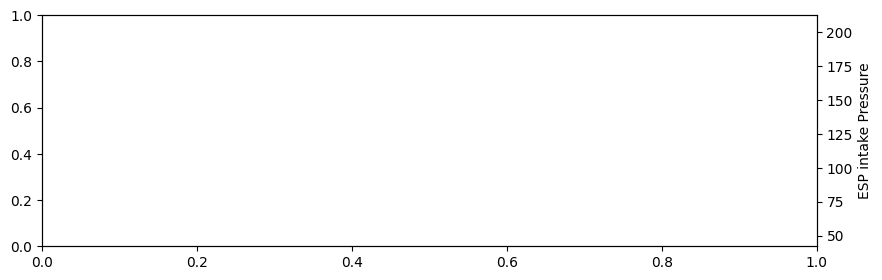

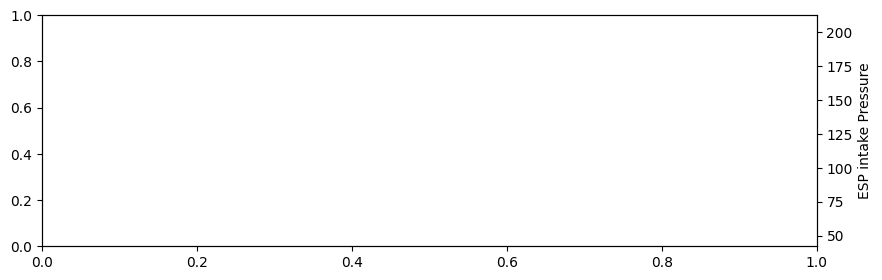

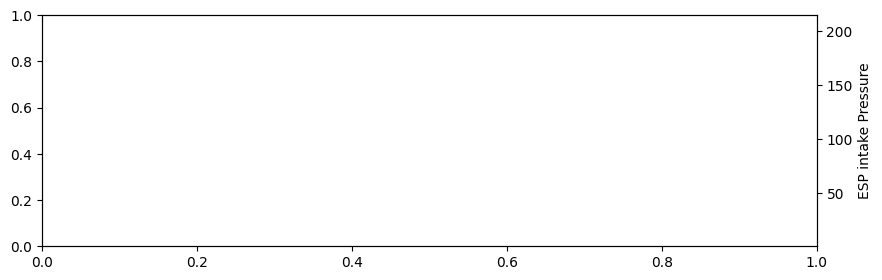

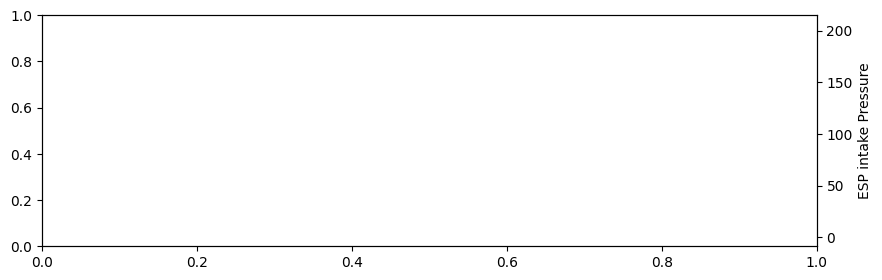

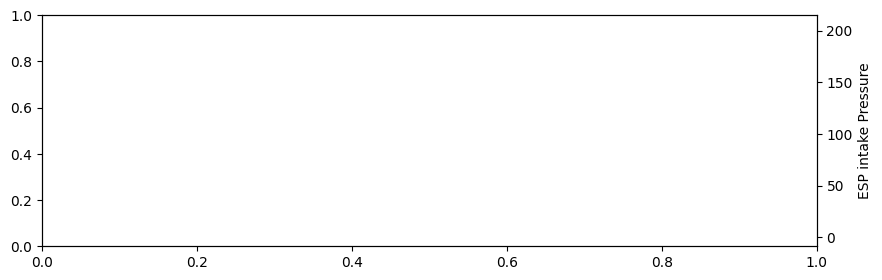

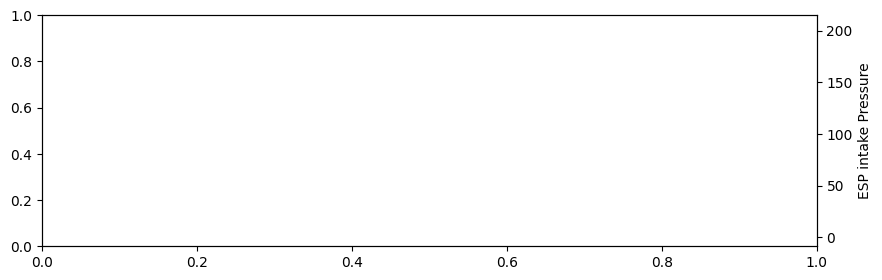

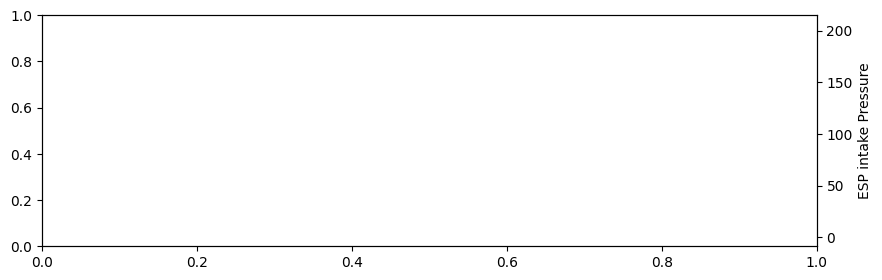

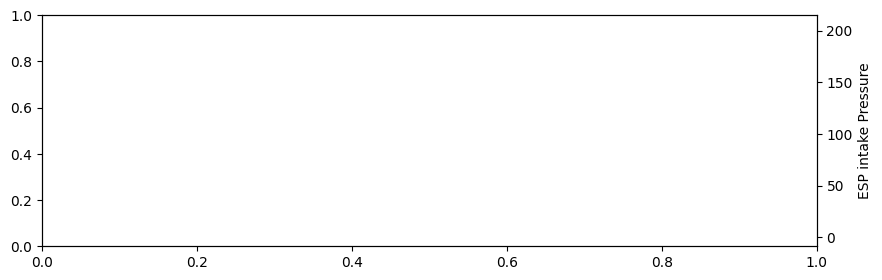

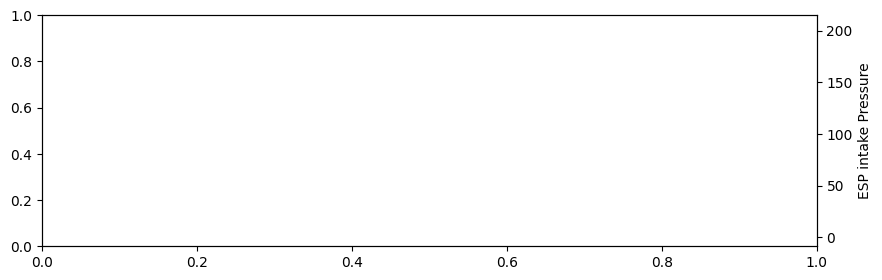

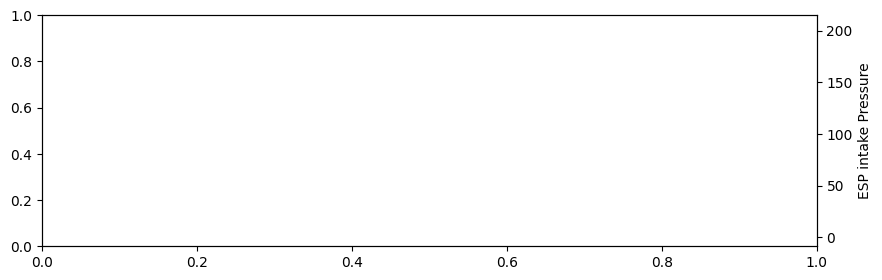

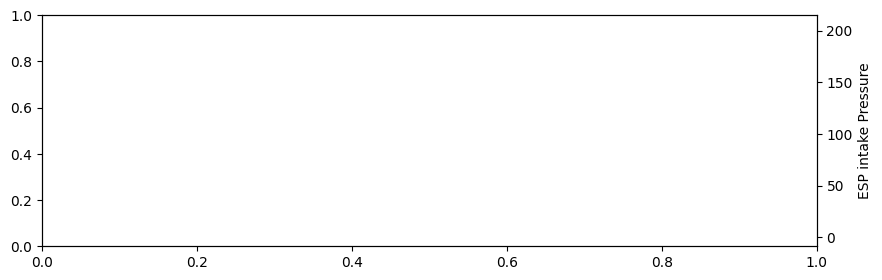

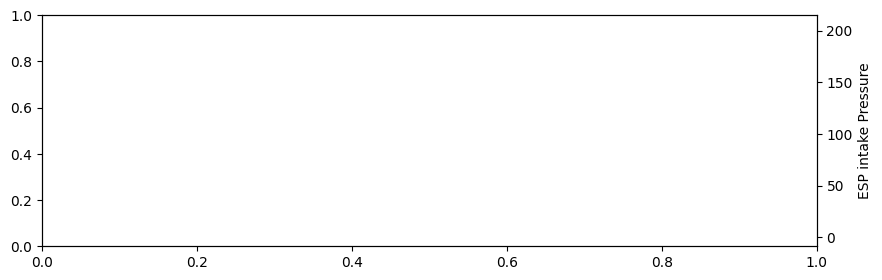

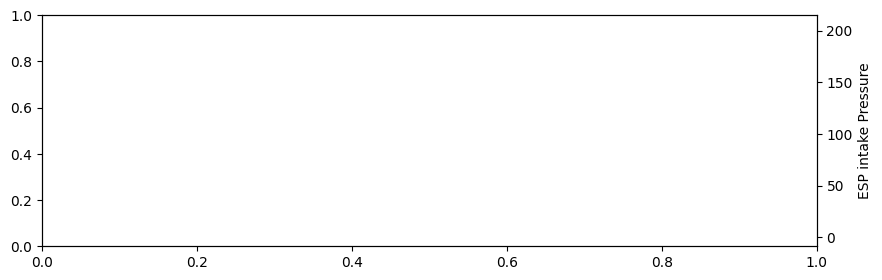

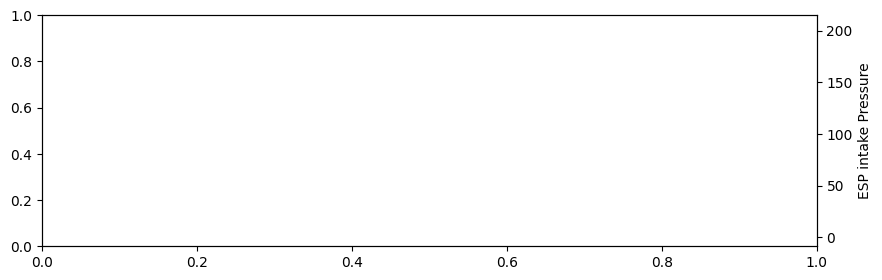

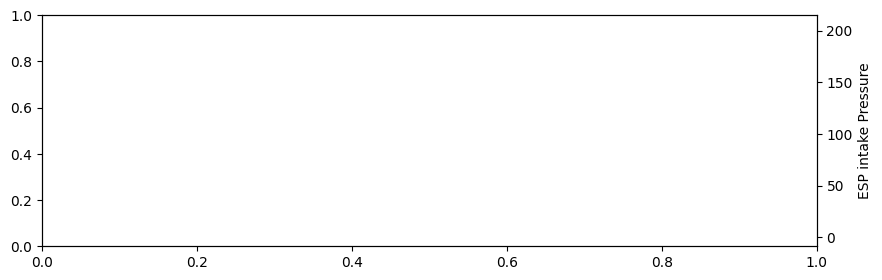

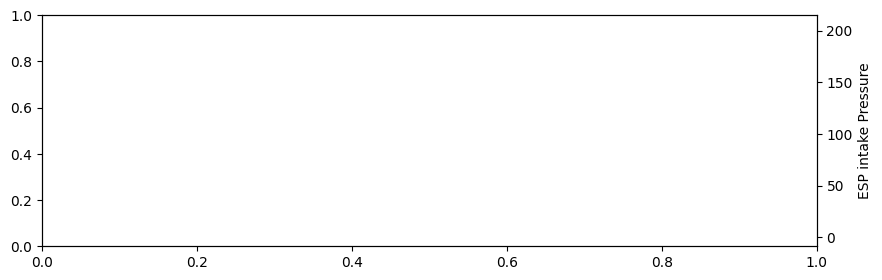

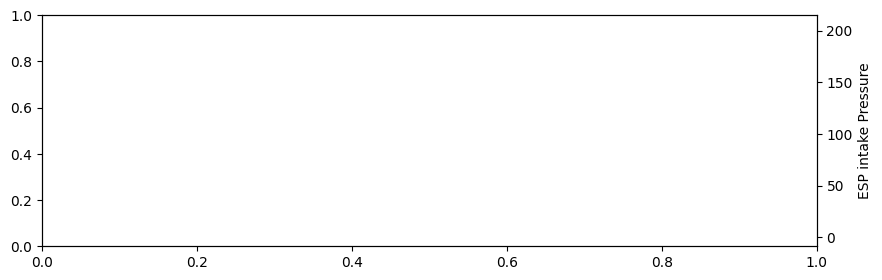

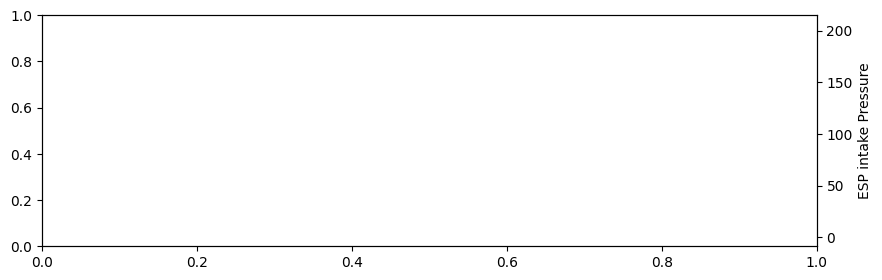

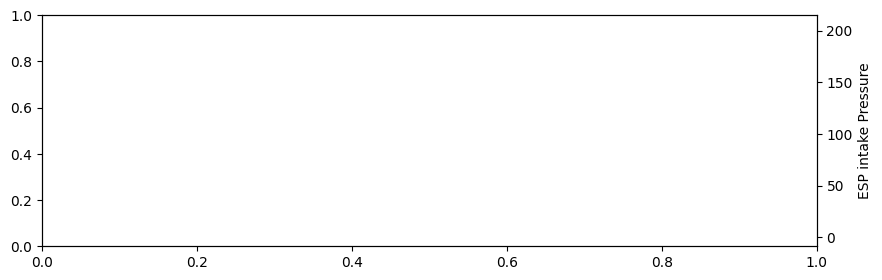

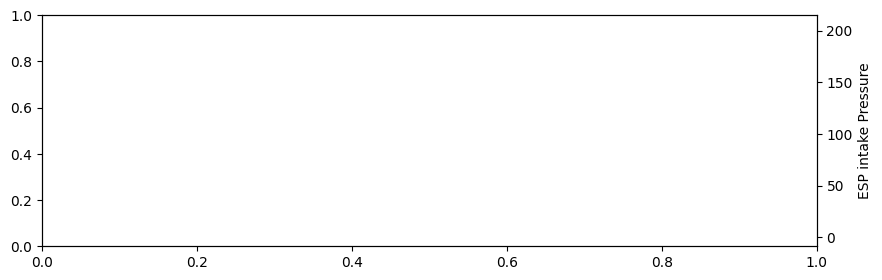

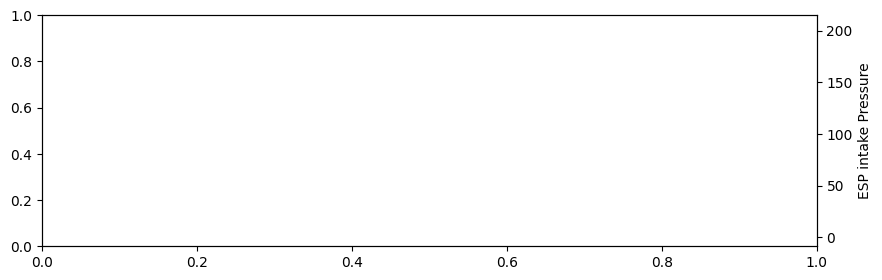

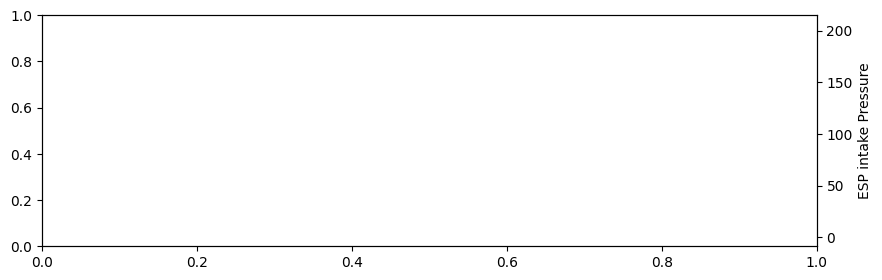

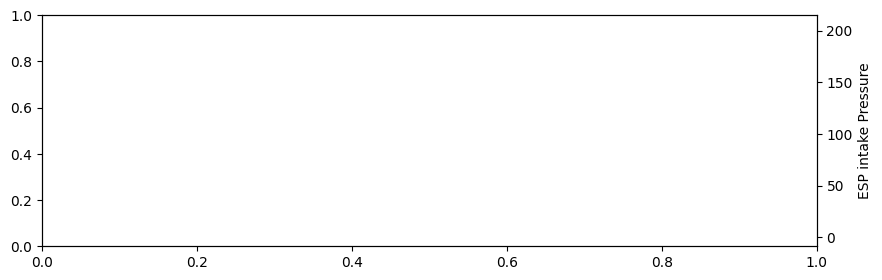

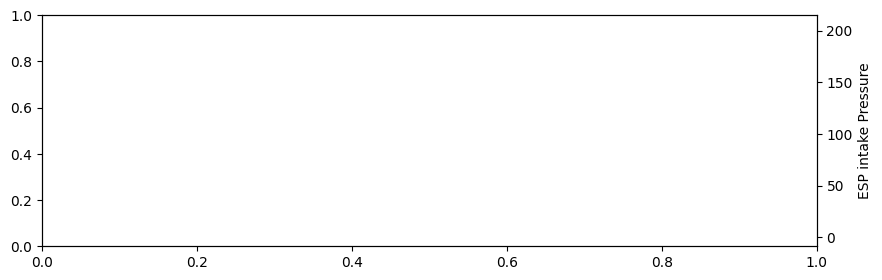

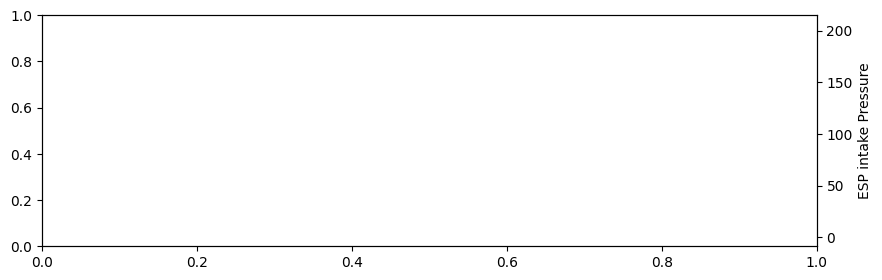

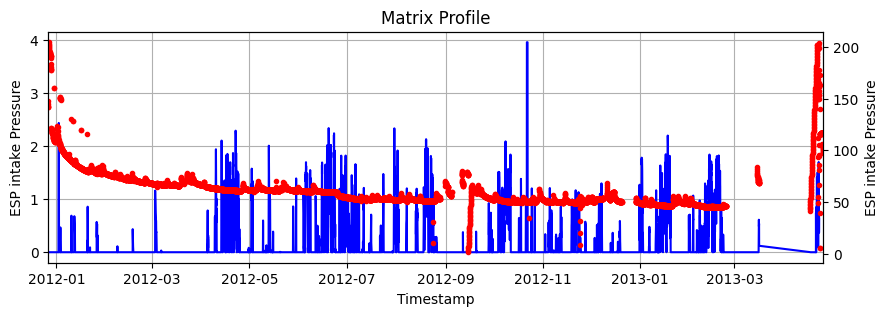

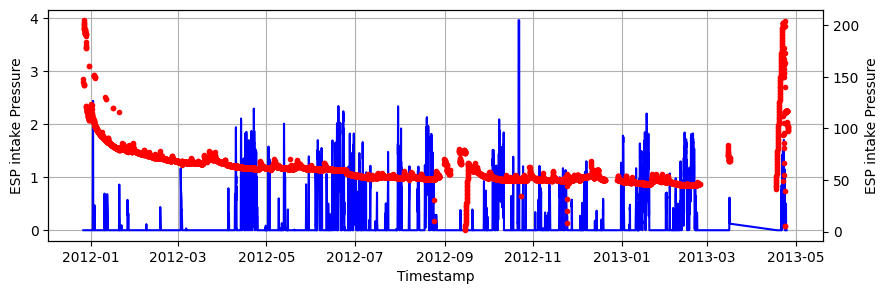

In [ ]:

from time import sleep
import matplotlib.pyplot as plt
plt.ion()  # turn on interactive mode

start = SUB_SIZE*12
builder = pyfade.DataFrameBuilder(sub_data.iloc[:start])
incremented_dataset = builder.set_extrapolation(pyfade.Extrapolation.CONSTANT)\
            .set_interpolation(pyfade.Interpolation.LINEAR)\
            .build()

w_builder = pyfade.WindowBuilder(incremented_dataset)
window = w_builder.set_window_size(SUB_SIZE).build()

group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.MatrixProfile, window)
group_builder.set_parameter('use_cuda',USE_CUDA)\
            .set_parameter('left_only',LEFT_ONLY)\
            .set_parameter('skip_start',SKIP_START)\
            .set_parameter('quantile_threshold',QUANTILE)
group_builder.build()

end = start + SUB_SIZE*7
k = 0
while end < sub_data.size:
    incremented_dataset.insert_data(sub_data.iloc[start:end])
    start = end
    end += SUB_SIZE*7

    if axs is not None:
        for ax in axs:
            ax.clear()

    MP = pd.DataFrame(window.mp.T,index=window.index)
    # fig, axs = pyfade.plot_multiple(MP,ylabel=incremented_dataset.dimensions,height=3,width=10);
    # pyfade.plot_multiple(sub_data.iloc[:end],style='.r',axs=axs,fig=fig)

    # axs[0].set_xlim([sub_data.index.min(),sub_data.index.max()])

    # axs[0].set_title('Matrix Profile');

    # fig.savefig(f"./Figures/Plot {k:04d}")
    k+= 1


incremented_dataset.insert_data(sub_data.iloc[start:])
MP = pd.DataFrame(window.mp.T,index=window.index)
fig, axs = pyfade.plot_multiple(MP,ylabel=incremented_dataset.dimensions,height=3,width=10);
pyfade.plot_multiple(sub_data.iloc[:end],style='.r',axs=axs,fig=fig)

# axs[0].set_title('Matrix Profile');
# fig.savefig(f"./Figures/Plot {k:04d}")



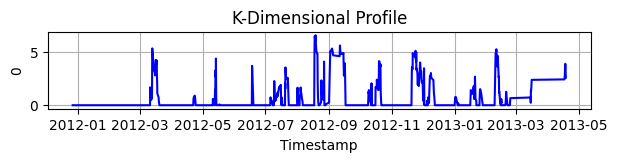

In [ ]:
group_builder = pyfade.FeatureGroupBuilder(pyfade.FeatureGroups.KProfile,window).build()

KDP = pd.DataFrame(window.kp.T,index=window.index)
fig, axs = pyfade.plot_multiple(KDP);
axs[0].set_title('K-Dimensional Profile');

In [ ]:
fig, axs = pyfade.plot_multiple(sub_data,style='xb',shutdowns=None,markersize=2,height=3,width=10);
pyfade.plot_multiple(MP,fig=fig,axs=axs,style='r-',linewidth=2);

# 3 - Decomposition

In [ ]:
pyfade.get_signal_decomp(sub_data,wavelet=WAVELET, create_plot=True, level = LEVELS, height= 2, width= 10,markersize=2,style='xb');

# 4 - MP wavelet

In [ ]:
MP_wave, _ =  pyfade.get_MP_from_wavelets(sub_data,SUB_SIZE,LEVELS, wavelet=WAVELET,on_signals=True,create_plot=True,plot_data=True,shutdowns=shutdowns,height=2, width=10,markersize=2,style=['r-','xb'],**mp_properties)

In [ ]:
KDP = pyfade.get_KDP(sub_data,SUB_SIZE,pre_calc_MP=MP_wave,shutdowns=shutdowns)
fig, axs = pyfade.plot_multiple(KDP,same_limits=False,style='r-',height=2, width=10);

In [ ]:
#sub_data.drop('ESP discharge temperature sensor',inplace=True,axis=1)
MPs = pyfade.wavelet_MP_from_KDP(sub_data,SUB_SIZE,DIMENSION,level=LEVELS,wavelet=WAVELET, on_signals=True,shutdowns=shutdowns, **mp_properties)

In [ ]:
no_outlier = sub_data.copy()
a = no_outlier.quantile(0.95,axis=0)
no_outlier[no_outlier>a] = np.nan
a = no_outlier.quantile(0.2,axis=0)
no_outlier[no_outlier<a] = np.nan

ind = np.where([col in ['VSD power frequency', 'Well head Temperature'] for col in no_outlier.columns])[0].astype(int)


fig, axs = pyfade.plot_multiple(no_outlier.iloc[:,ind],style='xb',markersize=2,height=2, width=10,shutdowns=None);
pyfade.plot_multiple([MPs[i] for i in ind],fig=fig,axs=axs,style='r-',linewidth=2,ylabel='Matrix Profile');

In [ ]:
fig.savefig('All_MP.png', format='png', dpi=300)

In [ ]:
KDP = pyfade.get_KDP(sub_data,SUB_SIZE,pre_calc_MP=MPs,shutdowns=shutdowns,**mp_properties)
fig, axs = pyfade.plot_multiple(KDP,same_limits=False,height=1, width=10,linewidth=2,style='r-');

In [ ]:
fig.savefig('All_KDP.png', format='png', dpi=300)